In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
salaries = [
    450000, 520000, 480000, 610000, 550000, 495000,
    530000, 575000, 620000, 510000, 465000, 590000,
    540000, 505000, 635000, 560000, 470000, 525000,
    600000, 580000, 490000, 545000, 615000, 500000,
    570000, 485000, 650000, 1500000, 2500000
]

df = pd.DataFrame({"Salary": salaries})

<Axes: xlabel='Salary'>

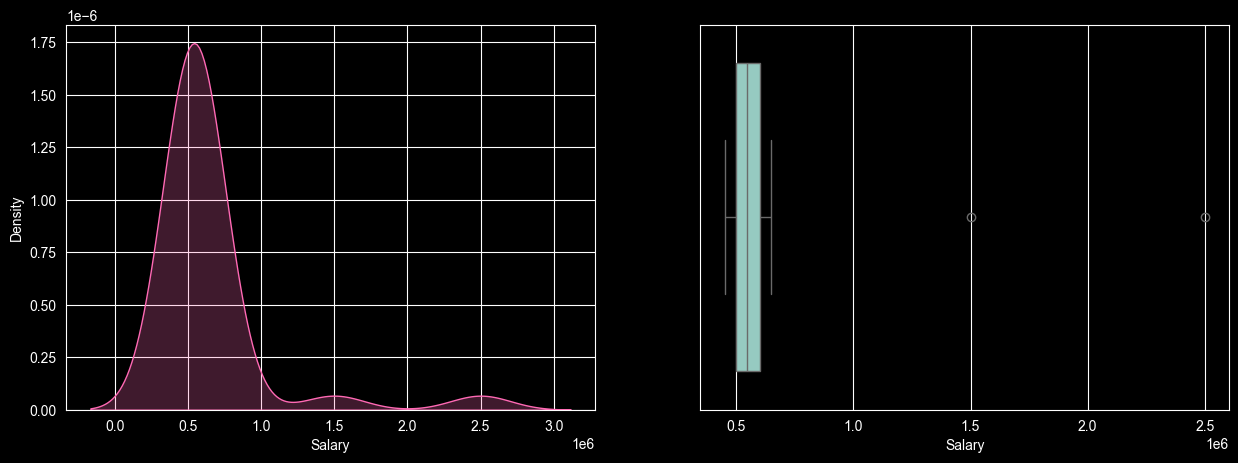

In [15]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.kdeplot(df["Salary"], fill=True, color="hotpink" ,ax=ax[0])
sns.boxplot(x=df["Salary"], fill=True, ax=ax[1])

In [16]:
df["log_salary"] = np.log(df["Salary"] + 0.000001)

<Axes: xlabel='log_salary'>

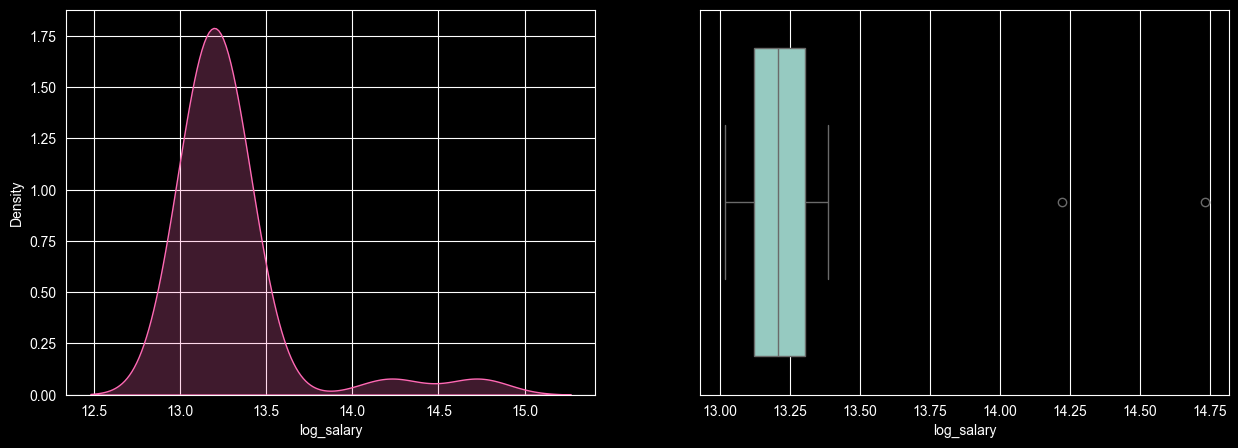

In [19]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.kdeplot(df["log_salary"], fill=True, color="hotpink" ,ax=ax[0])
sns.boxplot(x=df["log_salary"], fill=True, ax=ax[1])

## Z-score Normalization

In [20]:
salary_mean = df["Salary"].mean()
salary_std = df["Salary"].std()

df["zscore_salary"] = (df["Salary"] - salary_mean) / salary_std

In [23]:
outliers = df[abs(df["zscore_salary"]) > 3]

print(outliers)

     Salary  log_salary  zscore_salary
28  2500000   14.731801       4.613002


In [25]:
outlier_count = (abs(df["zscore_salary"]) > 3).sum()
print("Outliers:", outlier_count)

Outliers: 1


<Axes: xlabel='zscore_salary'>

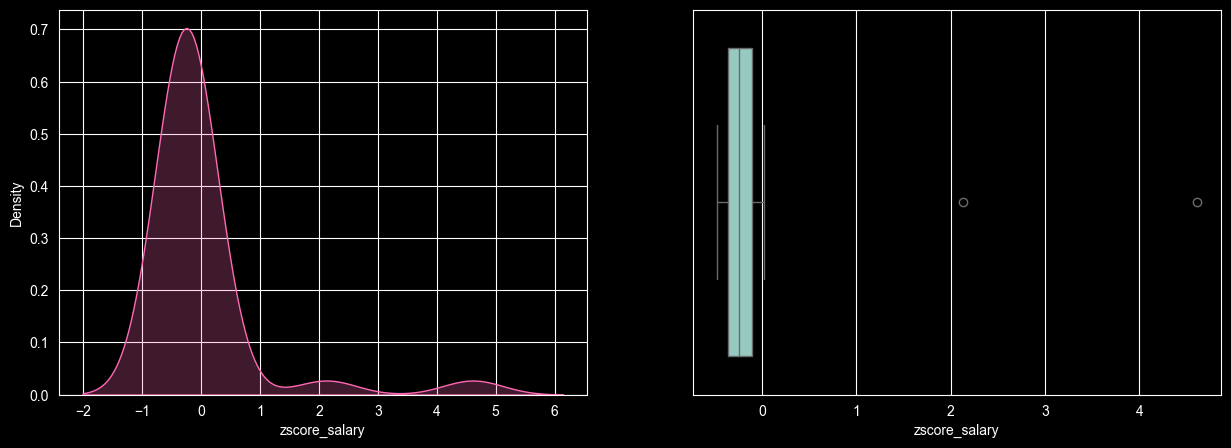

In [34]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.kdeplot(df["zscore_salary"], fill=True, color="hotpink" ,ax=ax[0])
sns.boxplot(x=df["zscore_salary"], fill=True, ax=ax[1])

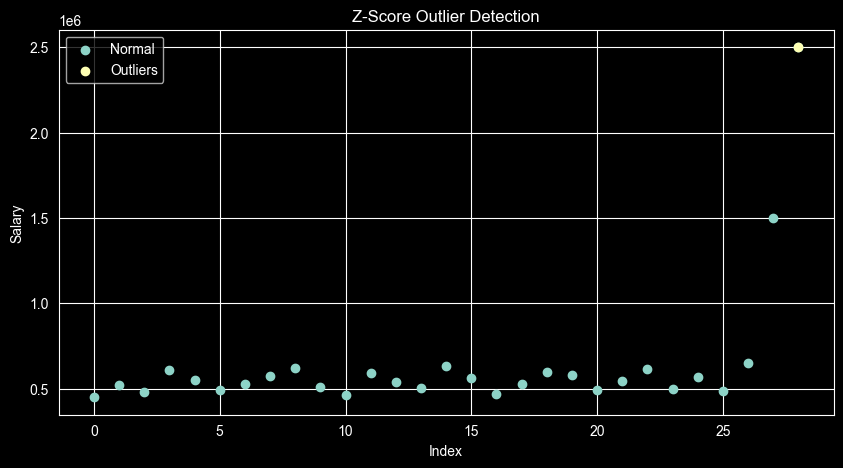

In [27]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

df["z_score"] = zscore(df["Salary"])

outliers = abs(df["z_score"]) > 3

plt.figure(figsize=(10, 5))

plt.scatter(df.index, df["Salary"], label="Normal")
plt.scatter(
    df.index[outliers],
    df.loc[outliers, "Salary"],
    label="Outliers"
)

plt.xlabel("Index")
plt.ylabel("Salary")
plt.title("Z-Score Outlier Detection")
plt.legend()

plt.show()

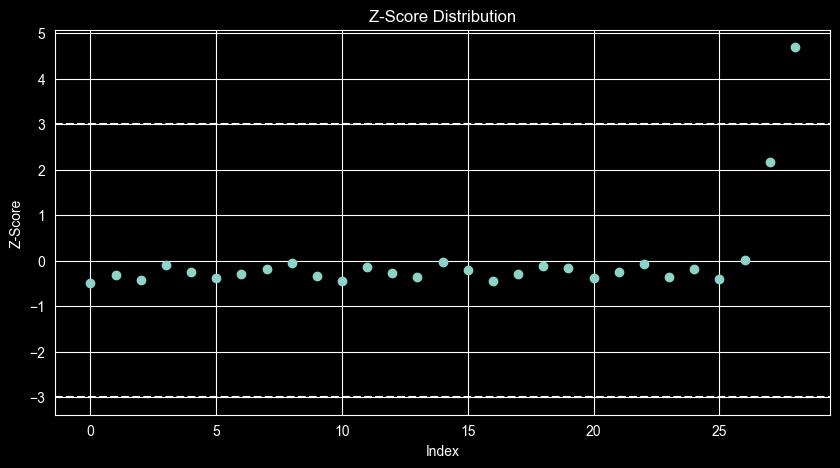

In [28]:
plt.figure(figsize=(10, 5))

plt.scatter(df.index, df["z_score"])

plt.axhline(3, linestyle="--")
plt.axhline(-3, linestyle="--")

plt.xlabel("Index")
plt.ylabel("Z-Score")
plt.title("Z-Score Distribution")

plt.show()

## IQR Method

In [36]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print()

print(outliers)

Lower bound: 350000.0
Upper bound: 750000.0

     Salary  log_salary  zscore_salary   z_score
27  1500000   14.220976       2.128056  2.165724
28  2500000   14.731801       4.613002  4.694655


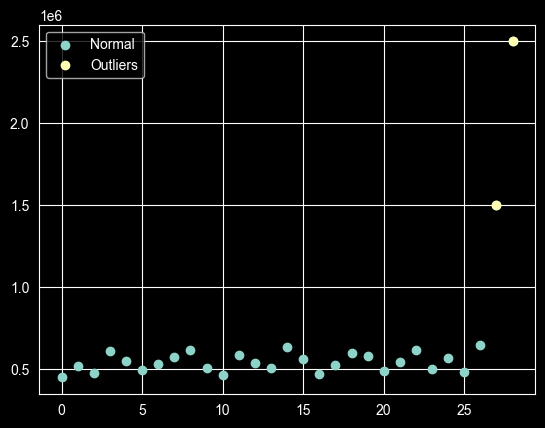

In [33]:
plt.scatter(df.index, df["Salary"], label="Normal")

plt.scatter(
    outliers.index,
    outliers["Salary"],
    label="Outliers"
)

plt.legend()
plt.show()

## Removing Outliers

In [37]:
df_no_outliers = df[(df["Salary"] > lower_bound) & (df["Salary"] < upper_bound)]

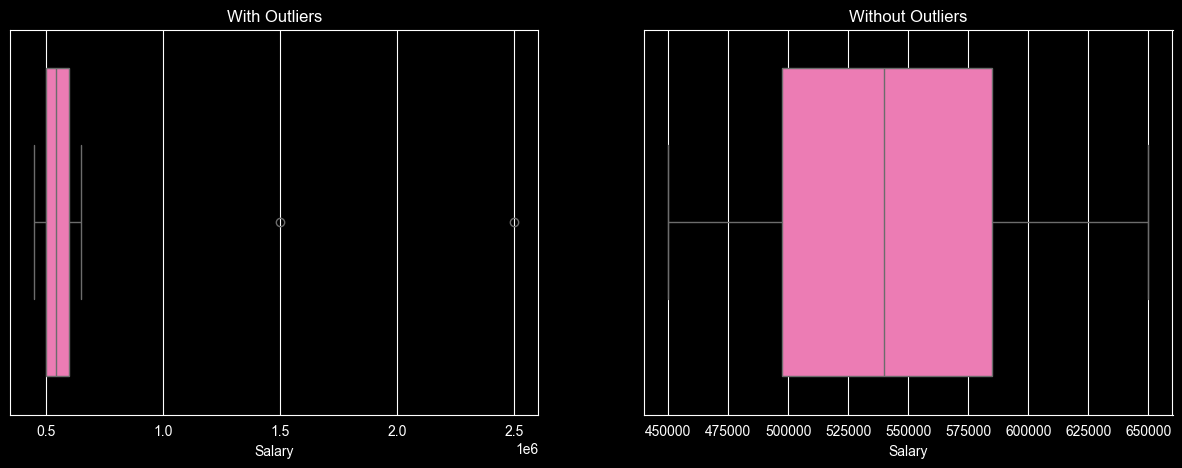

In [39]:
fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].set_title("With Outliers")
sns.boxplot(x=df["Salary"], fill=True, color="hotpink" ,ax=ax[0])

ax[1].set_title("Without Outliers")
sns.boxplot(x=df_no_outliers["Salary"], fill=True, color="hotpink", ax=ax[1])

plt.show()

## Cap (Winsorize) outliers

- Replace values outside the bounds with the boundary values:

In [40]:
df["salary_capped"] = df["Salary"].clip(lower=lower_bound, upper=upper_bound)

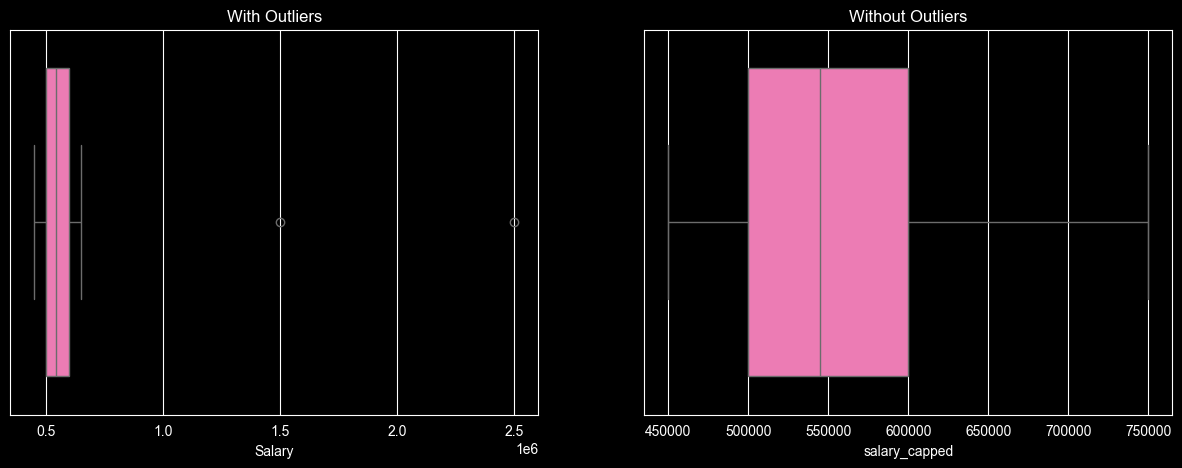

In [41]:
fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].set_title("With Outliers")
sns.boxplot(x=df["Salary"], fill=True, color="hotpink" ,ax=ax[0])

ax[1].set_title("Without Outliers")
sns.boxplot(x=df["salary_capped"], fill=True, color="hotpink", ax=ax[1])

plt.show()